In [27]:
import os
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle  # 안정성을 위해 명시적 임포트
from matplotlib.lines import Line2D

In [28]:
# ------------------------------------------------------------------------------
# [환경 설정] 한글 깨짐 방지 및 출력 경로 설정
# ------------------------------------------------------------------------------
# 운영체제에 맞는 한글 폰트를 설정하세요 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)

out_dir = "./" 
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# 데이터 로드
df = pd.read_csv('C:/Users/User/Desktop/연구지점 데이터 정리/데이터 취합중_연구과제_안정동위원소.csv', encoding='euc-kr')
plot_df = df.dropna(subset=['d15N', 'd18O']).copy()

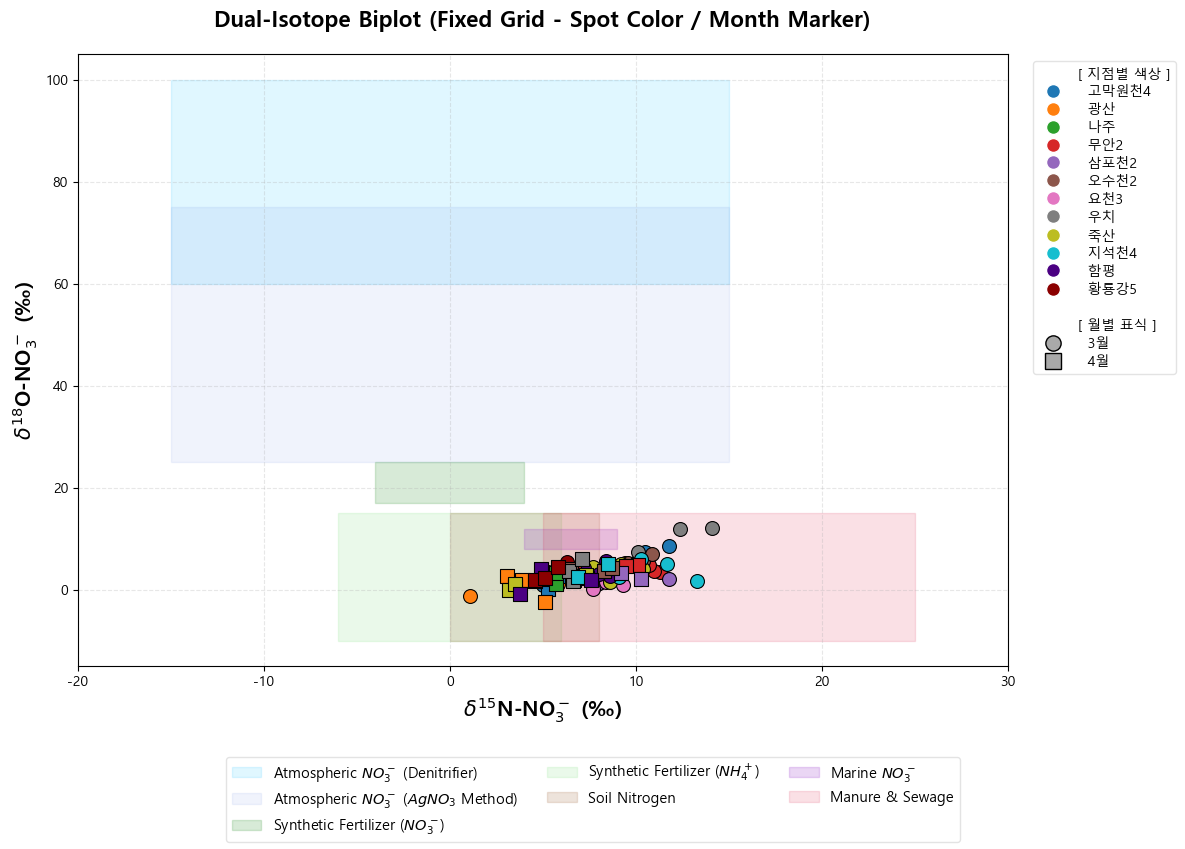

In [29]:
if not plot_df.empty:
    unique_months = sorted(plot_df['month'].unique())
    unique_spots = sorted(plot_df['spot'].unique())
    
    # 12개 지점 구분을 위한 고대비 컬러 매핑 (지점별 색상)
    distinct_colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
        '#4b0082', '#8b0000'
    ]
    color_map = {spot: distinct_colors[i % len(distinct_colors)] for i, spot in enumerate(unique_spots)}
    marker_map = {'3월': 'o', '4월': 's'} # 월별 도형

    # 그래프 생성
    fig, ax = plt.subplots(figsize=(12, 9))

    # --- 오염원 영역 패치 생성 및 추가 ---
    rect_handles = []
    r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
    r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
    r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
    r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
    r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
    r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
    r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')
    
    for r in [r1, r2, r3, r4, r5, r6, r7]:
        ax.add_patch(r)
        rect_handles.append(r)

    # 데이터 scatter 플로팅
    for (month, spot), group in plot_df.groupby(['month', 'spot']):
        ax.scatter(group['d15N'], group['d18O'], 
                   color=color_map[spot],       
                   marker=marker_map[month],     
                   s=100, edgecolors='k', linewidths=0.8, zorder=4)

    # 축 및 타이틀 디자인 설정
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Fixed Grid - Spot Color / Month Marker)", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlim(-20, 30)
    ax.set_ylim(-15, 105)

    # --------------------------------------------------------------------------
    # [복구 핵심 1] 우측 데이터 속성 범례를 ax 레벨의 메인 범례로 먼저 지정
    # --------------------------------------------------------------------------
    data_legend_elements = []
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 지점별 색상 ]'))
    for s in unique_spots:
        data_legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[s], markersize=10, label=f'  {s}'))
        
    data_legend_elements.append(Line2D([0], [0], color='none', label=''))
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 월별 표식 ]'))
    for m in unique_months:
        data_legend_elements.append(Line2D([0], [0], marker=marker_map[m], color='w', markerfacecolor='darkgray', markeredgecolor='k', markersize=11, label=f'  {m}'))

    # 우측 외부 범례 지정
    ax.legend(handles=data_legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1.0), 
              fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.35)

    # --------------------------------------------------------------------------
    # [복구 핵심 2] 하단 오염원 범례를 fig 레벨로 생성하여 잘림 현상을 원천 차단
    # --------------------------------------------------------------------------
    fig.legend(handles=rect_handles, loc='lower center', ncol=3, fontsize=10.5,
               frameon=True, facecolor='white', edgecolor='gainsboro')
    
    # 하단 범례가 축 라벨과 겹치지 않도록 플롯 하단 여백을 살짝 확보합니다.
    plt.subplots_adjust(bottom=0.2) 

    # 이미지 저장 및 화면 출력
    fig.savefig(os.path.join(out_dir, f"05_Dual-Isotope_fixed_swapped_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()

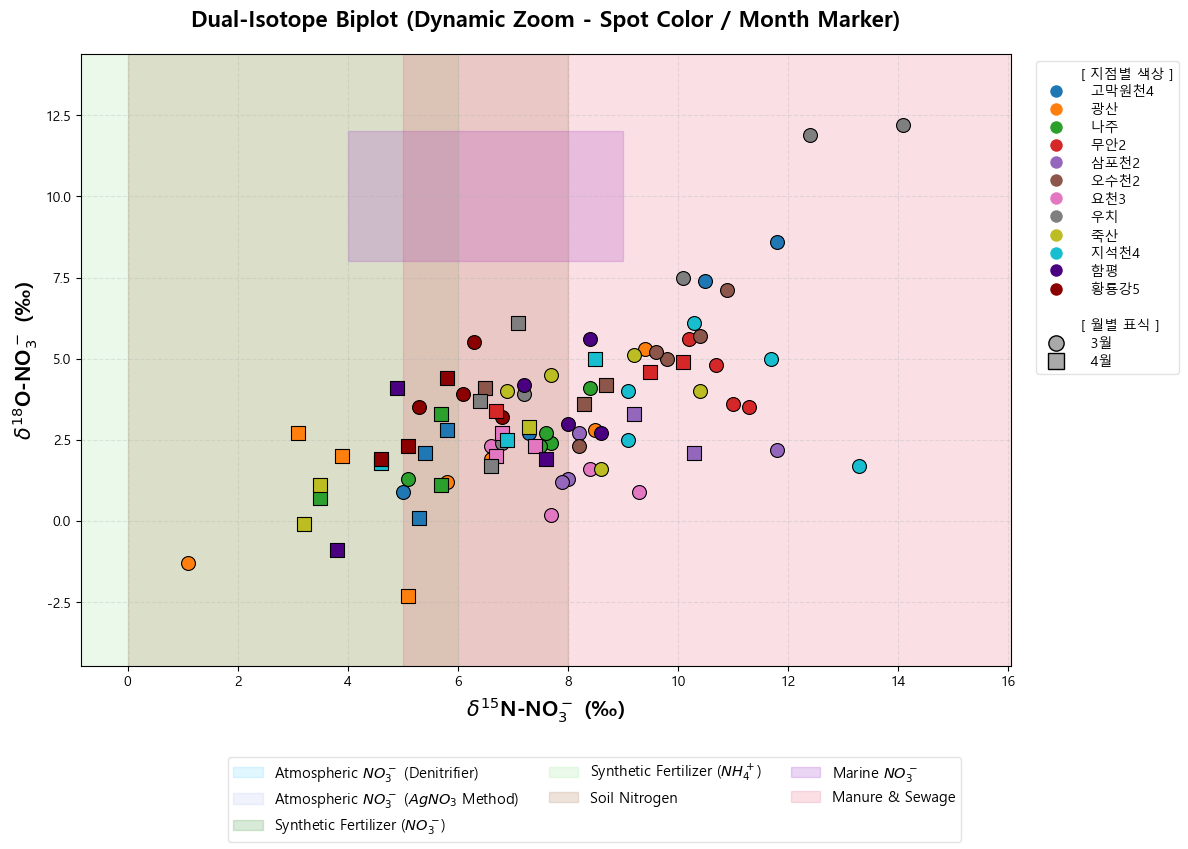

In [30]:
fig, ax = plt.subplots(figsize=(12, 9))

# 오염원 영역 패치 동일 생성
rect_handles = []
r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')

for r in [r1, r2, r3, r4, r5, r6, r7]:
    ax.add_patch(r)
    rect_handles.append(r)

# 데이터 scatter 플로팅
for (month, spot), group in plot_df.groupby(['month', 'spot']):
    ax.scatter(group['d15N'], group['d18O'], 
               color=color_map[spot], 
               marker=marker_map[month], 
               s=100, edgecolors='k', linewidths=0.8, zorder=4)

# 축 및 타이틀 설정
ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
ax.grid(alpha=0.3, linestyle='--')
ax.set_title("Dual-Isotope Biplot (Dynamic Zoom - Spot Color / Month Marker)", fontsize=16, fontweight='bold', pad=20)

# 동적 축 범위 및 15% 가독성 여백 자동 부여
x_min, x_max = plot_df['d15N'].min(), plot_df['d15N'].max()
y_min, y_max = plot_df['d18O'].min(), plot_df['d18O'].max()

x_padding = (x_max - x_min) * 0.15 if x_max != x_min else 1.0
y_padding = (y_max - y_min) * 0.15 if y_max != y_min else 1.0

ax.set_xlim(x_min - x_padding, x_max + x_padding)
ax.set_ylim(y_min - y_padding, y_max + y_padding)

# 우측 데이터 범례 설정 (ax 레벨 유지)
ax.legend(handles=data_legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1.0), 
          fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.35)

# 하단 오염원 범례 설정 (fig 레벨 격상으로 잘림 방지)
fig.legend(handles=rect_handles, loc='lower center', ncol=3, fontsize=10.5,
           frameon=True, facecolor='white', edgecolor='gainsboro')

# 하단 여백 확보
plt.subplots_adjust(bottom=0.2)

# 이미지 저장 및 화면 출력
fig.savefig(os.path.join(out_dir, f"05_Dual-Isotope_dynamic_swapped_{current_time}.png"), dpi=300, bbox_inches='tight')
plt.show()

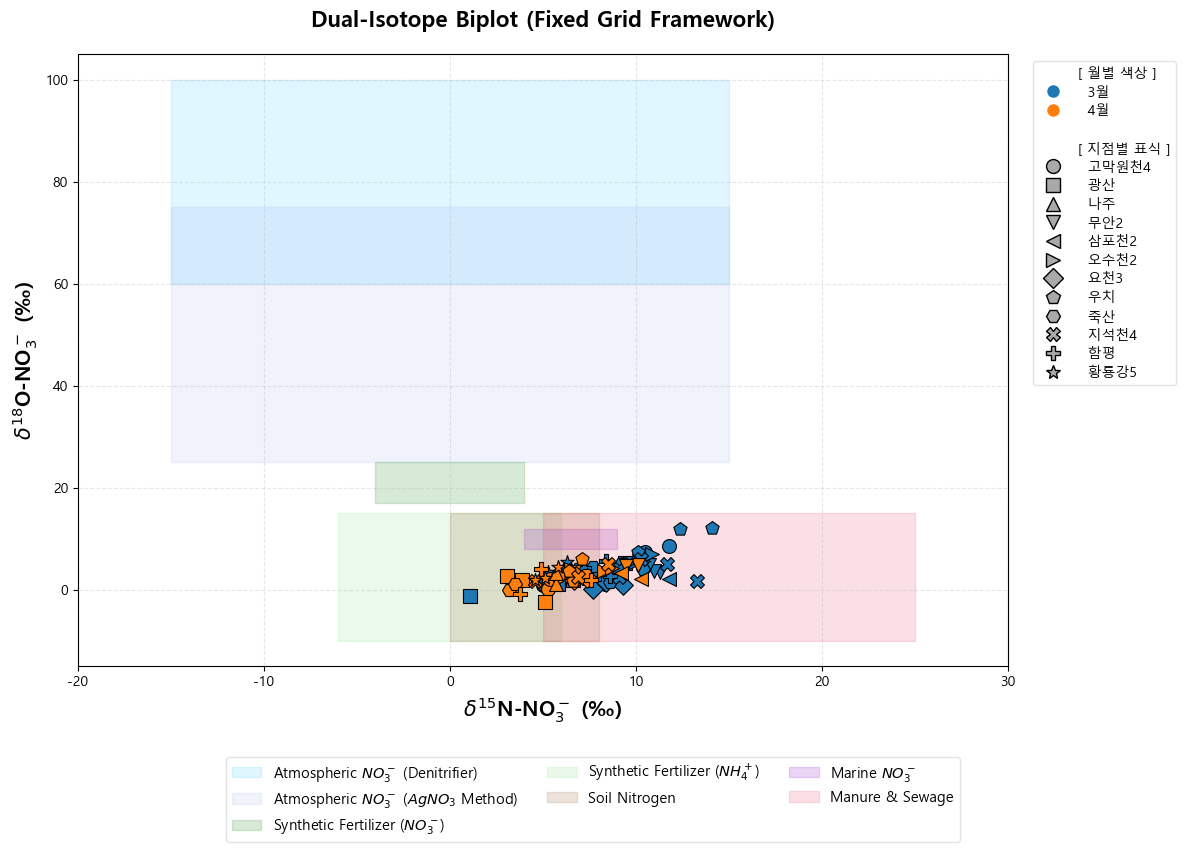

In [31]:
# ==============================================================================
# Dual-Isotope biplot (버전 1: 고정 축 범위)
# ==============================================================================
if not plot_df.empty:
    unique_months = sorted(plot_df['month'].unique())
    unique_spots = sorted(plot_df['spot'].unique())
    
    color_map = {'3월': '#1f77b4', '4월': '#ff7f0e'} 
    marker_list = ['o', 's', '^', 'v', '<', '>', 'D', 'p', 'H', 'X', 'P', '*']
    marker_map = {spot: marker_list[i % len(marker_list)] for i, spot in enumerate(unique_spots)}

    fig, ax = plt.subplots(figsize=(12, 9))

    # --------------------------------------------------------------------------
    # [수정 1] 사각형 오브젝트를 명시적 핸들 리스트(rect_handles)에 수집
    # --------------------------------------------------------------------------
    rect_handles = []
    
    r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
    r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
    r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
    r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
    r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
    r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
    r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')
    
    for r in [r1, r2, r3, r4, r5, r6, r7]:
        ax.add_patch(r)
        rect_handles.append(r)

    # 데이터 scatter 플로팅
    for (month, spot), group in plot_df.groupby(['month', 'spot']):
        ax.scatter(group['d15N'], group['d18O'], 
                   color=color_map[month], 
                   marker=marker_map[spot], 
                   s=100, edgecolors='k', linewidths=0.8, zorder=4)

    # 축 라벨 및 디자인 설정
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Fixed Grid Framework)", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlim(-20, 30)
    ax.set_ylim(-15, 105)

    # --------------------------------------------------------------------------
    # [수정 2] 범례 1: 우측 데이터 속성 범례를 ax 레벨의 메인 범례로 먼저 지정
    # --------------------------------------------------------------------------
    data_legend_elements = []
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 월별 색상 ]'))
    for m in unique_months:
        data_legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[m], markersize=10, label=f'  {m}'))
    data_legend_elements.append(Line2D([0], [0], color='none', label=''))
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 지점별 표식 ]'))
    for s in unique_spots:
        data_legend_elements.append(Line2D([0], [0], marker=marker_map[s], color='w', markerfacecolor='darkgray', markeredgecolor='k', markersize=10, label=f'  {s}'))

    ax.legend(handles=data_legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1.0), 
              fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.4)

    # --------------------------------------------------------------------------
    # [수정 3] 범례 2: 하단 오염원 영역 범례를 fig 레벨로 생성하여 잘림 현상을 원천 차단
    # --------------------------------------------------------------------------
    fig.legend(handles=rect_handles, loc='lower center', ncol=3, fontsize=10.5,
               frameon=True, facecolor='white', edgecolor='gainsboro')
    
    # 하단 범례 공간 확보를 위해 플롯 아래쪽 여백을 강제로 생성합니다.
    plt.subplots_adjust(bottom=0.2) 

    # 이미지 저장 및 출력
    fig.savefig(os.path.join(out_dir, f"05_Dual-Isotope_biplot_fixed_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("[경고] 데이터가 존재하지 않습니다.")

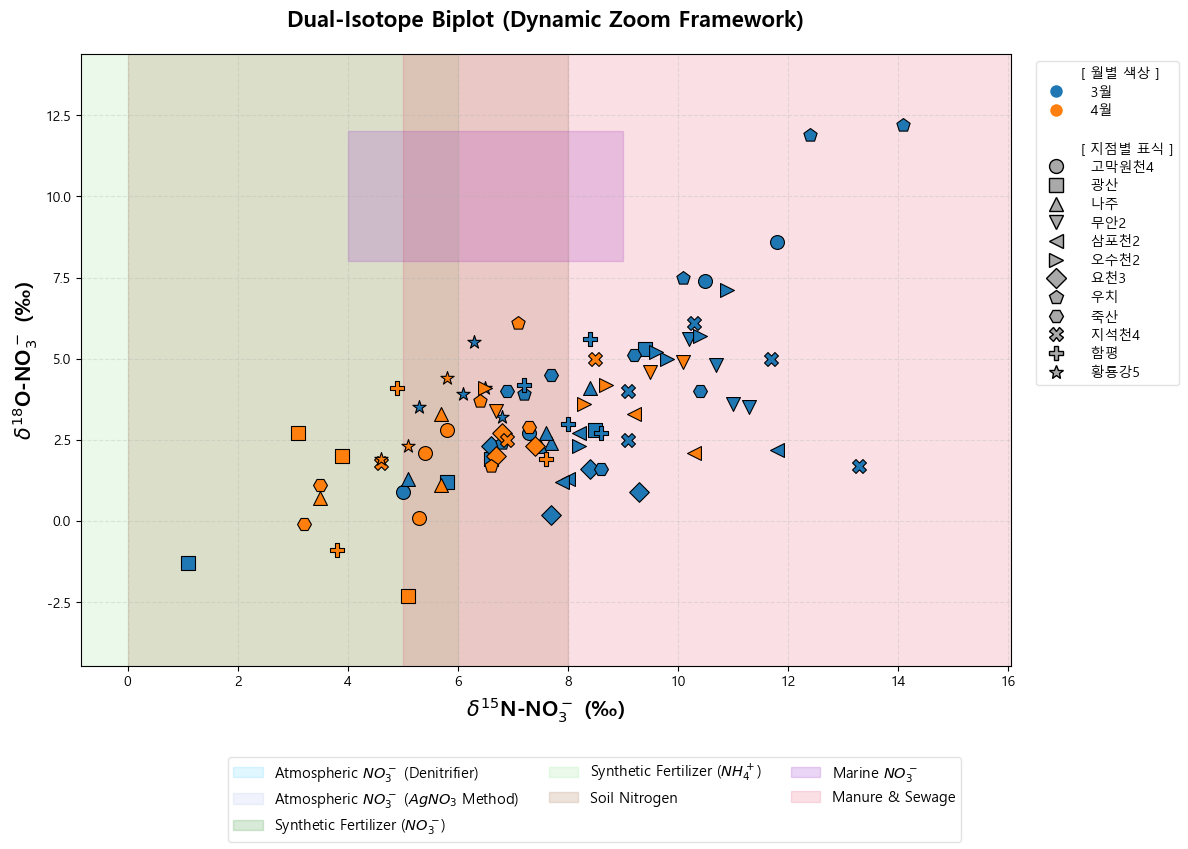

In [32]:
# ==============================================================================
# Dual-Isotope biplot (버전 2: 여백 기반 동적 축 범위 변형)
# ==============================================================================
if not plot_df.empty:
    unique_months = sorted(plot_df['month'].unique())
    unique_spots = sorted(plot_df['spot'].unique())
    
    color_map = {'3월': '#1f77b4', '4월': '#ff7f0e'} 
    marker_list = ['o', 's', '^', 'v', '<', '>', 'D', 'p', 'H', 'X', 'P', '*']
    marker_map = {spot: marker_list[i % len(marker_list)] for i, spot in enumerate(unique_spots)}

    fig, ax = plt.subplots(figsize=(12, 9))

    # --------------------------------------------------------------------------
    # [수정 1] 사각형 패치를 명시적 핸들 리스트(rect_handles)에 수집
    # --------------------------------------------------------------------------
    rect_handles = []
    
    r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
    r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
    r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
    r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
    r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
    r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
    r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')
    
    for r in [r1, r2, r3, r4, r5, r6, r7]:
        ax.add_patch(r)
        rect_handles.append(r)

    # 데이터 scatter 플로팅
    for (month, spot), group in plot_df.groupby(['month', 'spot']):
        ax.scatter(group['d15N'], group['d18O'], 
                   color=color_map[month], 
                   marker=marker_map[spot], 
                   s=100, edgecolors='k', linewidths=0.8, zorder=4)

    # 축 라벨 및 디자인 설정
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Dynamic Zoom Framework)", fontsize=16, fontweight='bold', pad=20)

    # 동적 스케일링 설정
    x_min, x_max = plot_df['d15N'].min(), plot_df['d15N'].max()
    y_min, y_max = plot_df['d18O'].min(), plot_df['d18O'].max()
    
    x_padding = (x_max - x_min) * 0.15 if x_max != x_min else 1.0
    y_padding = (y_max - y_min) * 0.15 if y_max != y_min else 1.0
    
    ax.set_xlim(x_min - x_padding, x_max + x_padding)
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    # --------------------------------------------------------------------------
    # [수정 2] 범례 1: 우측 데이터 속성 범례 빌드 및 ax 고정
    # --------------------------------------------------------------------------
    data_legend_elements = []
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 월별 색상 ]'))
    for m in unique_months:
        data_legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[m], markersize=10, label=f'  {m}'))
    data_legend_elements.append(Line2D([0], [0], color='none', label=''))
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 지점별 표식 ]'))
    for s in unique_spots:
        data_legend_elements.append(Line2D([0], [0], marker=marker_map[s], color='w', markerfacecolor='darkgray', markeredgecolor='k', markersize=10, label=f'  {s}'))

    ax.legend(handles=data_legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1.0), 
              fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.4)

    # --------------------------------------------------------------------------
    # [수정 3] 범례 2: 하단 오염원 범례를 fig 레벨로 캔버스 최하단 배치 (잘림 현상 해결)
    # --------------------------------------------------------------------------
    fig.legend(handles=rect_handles, loc='lower center', ncol=3, fontsize=10.5,
               frameon=True, facecolor='white', edgecolor='gainsboro')
    
    # 하단 레이아웃 여백 제어
    plt.subplots_adjust(bottom=0.2) 

    # 이미지 저장 및 출력
    fig.savefig(os.path.join(out_dir, f"05_Dual-Isotope_biplot_dynamic_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("[경고] 데이터가 존재하지 않습니다.")